In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import umap

In [2]:
def preprocess_dataset(x, y):
    x = tf.expand_dims(x, -1)
    x = tf.image.resize(x, [224, 224])
    x = tf.image.grayscale_to_rgb(x)
    x = x / 255.0
    y = to_categorical(y, num_classes=10)
    return x, y


In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train[:2000]
y_train = y_train[:2000]
x_test = x_test[:1000]
y_test = y_test[:1000]

x_train, y_train = preprocess_dataset(x_train, y_train)
x_test, y_test = preprocess_dataset(x_test, y_test)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
input = Input((224,224,3))
x = Flatten()(input)
x = Dense(3, activation='relu')(x)
x = Dense(2, activation='relu')(x)
x = Dense(3, activation='relu')(x)
output = Dense(10, activation='softmax')(x)

model = Model(inputs=input, outputs=output)


training the model using the tf.GradientTape()

In [5]:
loss_fn = tf.keras.losses.CategoricalCrossentropy()
optimizer = tf.keras.optimizers.AdamW()

In [6]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(1000).batch(32)
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(32)


In [7]:
train_loss, train_acc = [], []
for epoch in range(5):
    print(f"\nEpoch {epoch+1}")

    for x_batch, y_batch in train_ds:
        with tf.GradientTape() as tape:
            logits = model(x_batch, training=True)
            loss = loss_fn(y_batch, logits)
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        acc = tf.keras.metrics.categorical_accuracy(y_batch, logits)
        train_loss.append(loss.numpy())
        train_acc.extend(acc.numpy())

    print(f"Train Loss: {np.mean(train_loss):.4f}, Train Accuracy: {np.mean(train_acc):.4f}")



Epoch 1
Train Loss: 2.2520, Train Accuracy: 0.1455

Epoch 2
Train Loss: 2.1917, Train Accuracy: 0.1685

Epoch 3
Train Loss: 2.1495, Train Accuracy: 0.1787

Epoch 4
Train Loss: 2.1199, Train Accuracy: 0.1822

Epoch 5
Train Loss: 2.0984, Train Accuracy: 0.1858


In [8]:
test_loss, test_acc = [], []

for x_batch, y_batch in test_ds:
    logits = model(x_batch, training=False)
    loss = loss_fn(y_batch, logits)
    acc = tf.keras.metrics.categorical_accuracy(y_batch, logits)

    test_loss.append(loss.numpy())
    test_acc.extend(acc.numpy())

print(f"\nTest Loss: {np.mean(test_loss):.4f}, Test Accuracy: {np.mean(test_acc):.4f}")




Test Loss: 2.0710, Test Accuracy: 0.1810


In [9]:
y_pred_probs = model.predict(x_test)

y_pred_classes = np.argmax(y_pred_probs, axis=1)

y_true_classes = np.argmax(y_test, axis=1)

accuracy = np.mean(y_pred_classes == y_true_classes)
print(f"Prediction Accuracy: {accuracy:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step
Prediction Accuracy: 0.1810


In [10]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.2304 - loss: 1.9924 - val_accuracy: 0.1960 - val_loss: 2.0514
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.2060 - loss: 1.9777 - val_accuracy: 0.1950 - val_loss: 2.0696
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2187 - loss: 1.9514 - val_accuracy: 0.1980 - val_loss: 2.0251
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2160 - loss: 1.9355 - val_accuracy: 0.2110 - val_loss: 2.0275
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2309 - loss: 1.9094 - val_accuracy: 0.2330 - val_loss: 1.9958


In [11]:
# --- Predict on test data ---
y_pred_probs = model.predict(x_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# --- Evaluate test accuracy ---
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2263 - loss: 1.9948
Test Accuracy: 0.2330


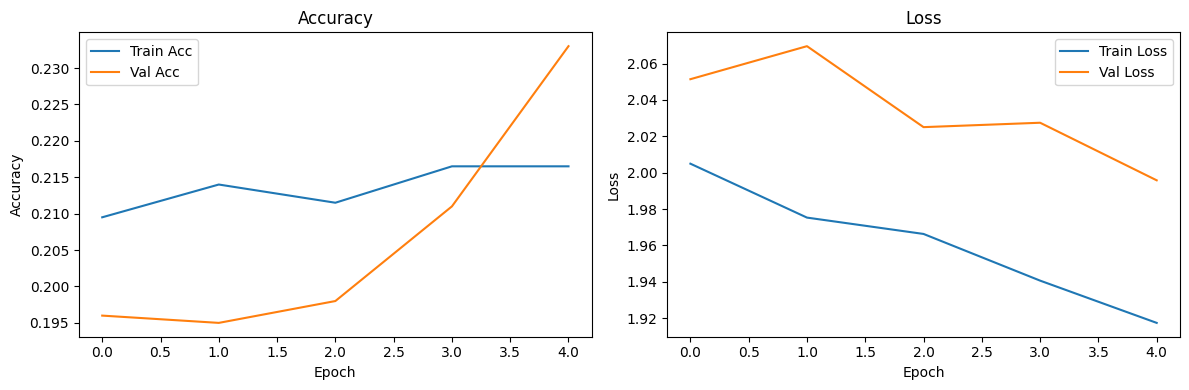

In [12]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
